# Week 7 — CNNs for Melanoma Classification (Sprint 2)
## Melanoma Skin Cancer Classification: Benign vs Malignant

**BinX Tech — AI & Machine Learning Internship Program | Phase 3, Sprint 2**

This notebook advances the Phase 3 core model from Week 6. Sprint 1 proved that a
plain Dense network cannot beat a simple baseline on raw image pixels. This sprint
fixes that by using the architecture that actually fits image data: a CNN.

## Sprint 2 Planning

**Sprint Goal:** Build a CNN-based core model that beats the Week 6 baseline
(Logistic Regression, 86.85% accuracy) and the best Week 6 neural network (NN v3,
82.60%), by using an architecture that respects the spatial structure of images.

**Retrospective improvement carried forward from Sprint 1:** change one
hyperparameter at a time per experiment, instead of changing two at once (like the
learning rate + dropout change between v2 and v3 last sprint).

**Backlog for this sprint:**
- [ ] Reload the dataset WITHOUT flattening (keep spatial structure)
- [ ] Explain why the Week 6 Dense network failed
- [ ] Hand-coded convolution demo (edge detection filter + feature map)
- [ ] Build a CNN from scratch, train, evaluate (v1)
- [ ] Add data augmentation, retrain (v2)
- [ ] Apply transfer learning with MobileNetV2 (v3)
- [ ] Compare all models (baseline, Week 6 NNs, CNN v1/v2/v3) in one table
- [ ] Sprint Review and Retrospective

**Definition of done:** Notebook runs top to bottom without errors, every model's
score is recorded and compared to the baseline, and the final architecture choice
is justified in Markdown.

In [31]:
# import data from kaggle

from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!mkdir -p ~/.kaggle
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

!pip install kaggle -q
!kaggle datasets download -d ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant
!unzip -q -o melanoma-skin-cancer-dataset-benign-vs-malignant.zip -d melanoma_data

Dataset URL: https://www.kaggle.com/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant
License(s): MIT
melanoma-skin-cancer-dataset-benign-vs-malignant.zip: Skipping, found more recently modified local copy (use --force to force download)


## 0. Why the Week 6 Dense Network Failed

Last sprint I flattened every image into a 1D array of 12,288 numbers before
feeding it to a Dense network:

X_train_flat = X_train_norm.reshape(X_train_norm.shape[0],-1)


This threw away all spatial information — the Dense network had no way to know
that pixel 500 and pixel 501 might be neighbors in the original image. It treated
every pixel as an independent feature, exactly like a tabular dataset. That's why
none of the three neural network versions (70.70%, 82.20%, 82.60%) beat the
86.85% Logistic Regression baseline.

A CNN fixes this by keeping the image's 2D shape and sliding small filters across
it, so it can actually learn spatial patterns like edges, curves, and textures —
which is exactly what distinguishes benign from malignant lesions.

In [32]:
# Reload the same dataset as Week 6, but this time DO NOT flatten it.
# We reuse the loading logic from Week 6's Sprint1.ipynb.

import numpy as np
from PIL import Image
import os

IMG_SIZE = 64

def load_images_from_folder(folder_path, label, img_size=IMG_SIZE):
    images = []
    labels = []
    files = os.listdir(folder_path)
    for fname in files:
        try:
            img = Image.open(os.path.join(folder_path, fname)).convert('RGB')
            img = img.resize((img_size, img_size))
            images.append(np.array(img))
            labels.append(label)
        except Exception as e:
            print(f'Problem with image {fname}: {e}')
    return images, labels

train_benign_imgs, train_benign_labels = load_images_from_folder('melanoma_data/train/Benign', 0)
train_malignant_imgs, train_malignant_labels = load_images_from_folder('melanoma_data/train/Malignant', 1)

X_train = np.array(train_benign_imgs + train_malignant_imgs)
y_train = np.array(train_benign_labels + train_malignant_labels)

test_benign_imgs, test_benign_labels = load_images_from_folder('melanoma_data/test/Benign', 0)
test_malignant_imgs, test_malignant_labels = load_images_from_folder('melanoma_data/test/Malignant', 1)

X_test = np.array(test_benign_imgs + test_malignant_imgs)
y_test = np.array(test_benign_labels + test_malignant_labels)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (11879, 64, 64, 3)
X_test shape: (2000, 64, 64, 3)


In [33]:
from sklearn.utils import shuffle

# Normalize pixel values to 0-1
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Shuffle (data was loaded in order: all Benign, then all Malignant)
X_train_norm, y_train = shuffle(X_train_norm, y_train, random_state=42)
X_test_norm, y_test = shuffle(X_test_norm, y_test, random_state=42)

# CRITICAL DIFFERENCE FROM WEEK 6: we do NOT reshape/flatten here.
# Shape stays (n_samples, 64, 64, 3) so the CNN can see spatial structure.
print(f'X_train_norm shape (kept 2D): {X_train_norm.shape}')
print(f'X_test_norm shape (kept 2D): {X_test_norm.shape}')

X_train_norm shape (kept 2D): (11879, 64, 64, 3)
X_test_norm shape (kept 2D): (2000, 64, 64, 3)


## 1. Understanding Convolution Before Building the CNN

Before building the full network, I want to see convolution actually working on
one of my own melanoma images — the same way I manually coded a forward pass in
Week 6 before trusting `model.fit()`.

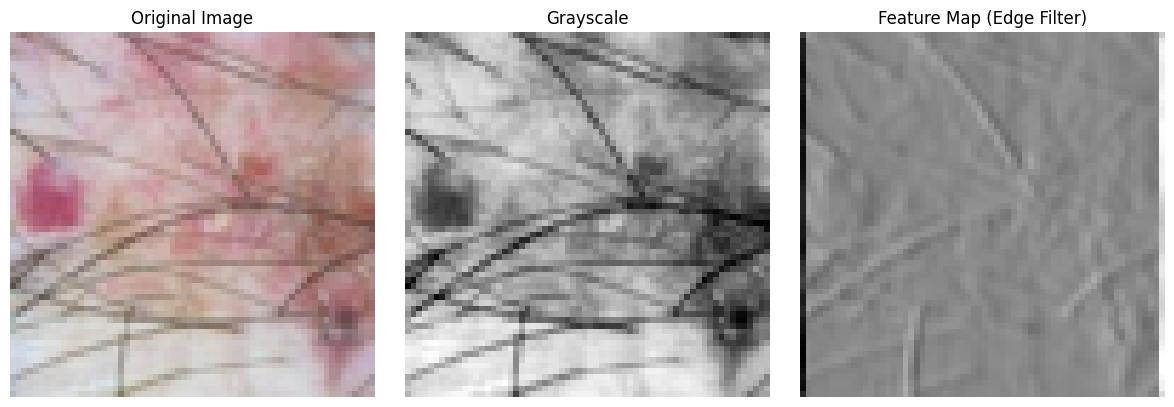

In [34]:
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Take one sample image, convert to grayscale for a simple demo
sample_img = X_train_norm[0]
gray_img = np.mean(sample_img, axis=2)  # simple grayscale conversion

# A classic vertical edge detection filter (Sobel-style)
edge_filter = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

feature_map = convolve2d(gray_img, edge_filter, mode='same')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_img)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(gray_img, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

axes[2].imshow(feature_map, cmap='gray')
axes[2].set_title('Feature Map (Edge Filter)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Result:** the edge filter highlights boundaries in the lesion — exactly where
pixel intensity changes sharply (the edge of a mole, a color transition). This
one 3x3 filter (9 weights) was reused across the *entire* image to produce this
feature map. A Dense layer doing the same job on a 64x64 image would need a
separate weight for every single pixel position — thousands of times more
parameters for the same job. This is parameter sharing, and it's the core reason
CNNs are efficient on images.

**Data type confirmation:** my project is image data (Melanoma Benign vs
Malignant), so per the Week 7 architecture-matching table, the correct core
model is a **CNN**, with transfer learning as the recommended approach for
strong results on a relatively small medical imaging dataset.

## 2. Building a CNN From Scratch (v1)

Now I'll build my first real CNN. Unlike Week 6's Dense network, this one keeps
the image's 2D shape throughout the convolution/pooling stages, and only
flattens at the very end — after the spatial features have already been
extracted, not before.

In [35]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn_v1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_v1.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,337 (3.14 MB)

 Trainable params: 822,337 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
cnn_v1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_cnn_v1 = cnn_v1.fit(
    X_train_norm, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32
)

Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7926 - loss: 0.4392 - val_accuracy: 0.8384 - val_loss: 0.3640
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8493 - loss: 0.3462 - val_accuracy: 0.8556 - val_loss: 0.3340
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8530 - loss: 0.3297 - val_accuracy: 0.8577 - val_loss: 0.3239
Epoch 4/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8596 - loss: 0.3172 - val_accuracy: 0.8607 - val_loss: 0.3327
Epoch 5/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8692 - loss: 0.3022 - val_accuracy: 0.8565 - val_loss: 0.3350
Epoch 6/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8753 - loss: 0.2920 - val_accuracy: 0.8506 - val_loss: 0.3375
Epoch 7/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8793 - loss: 0.2751 - val_accuracy: 0.8725 - val_loss: 0.3020
Epoch 8/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8809 - loss: 0.2695 - val_accuracy: 0

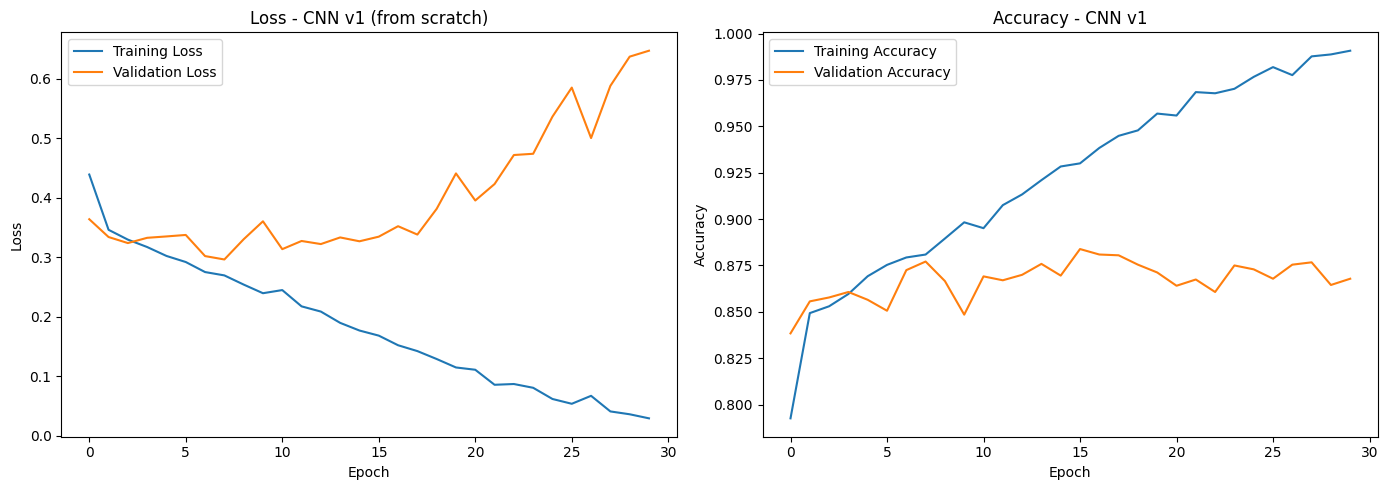

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn_v1.history['loss'], label='Training Loss')
axes[0].plot(history_cnn_v1.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss - CNN v1 (from scratch)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_cnn_v1.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_cnn_v1.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy - CNN v1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_v1_curves.png', dpi=150)
plt.show()

In [38]:
test_loss_cnn1, test_acc_cnn1 = cnn_v1.evaluate(X_test_norm, y_test)

print(f'\n=== Comparison So Far ===')
print(f'Baseline (Logistic Regression - Week 6):        86.85%')
print(f'NN v3 (best Dense network - Week 6):             82.60%')
print(f'CNN v1 (from scratch, no augmentation):          {test_acc_cnn1*100:.2f}%')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9110 - loss: 0.4272

=== Comparison So Far ===
Baseline (Logistic Regression - Week 6):        86.85%
NN v3 (best Dense network - Week 6):             82.60%
CNN v1 (from scratch, no augmentation):          91.10%


**Diagnosis:** CNN v1 scored 91.10% test accuracy, beating the Week 6
baseline (86.85%) by ~4.25 points and the best Week 6 dense network
(82.60%) by even more. However, the training curves show clear overfitting:
training accuracy climbs above 99% while validation accuracy plateaus around
86-88%, and validation loss starts rising after roughly epoch 10 while
training loss keeps dropping toward zero. So the raw test accuracy is
strong, but the model is starting to memorize the training set rather than
generalize cleanly.

## 3. Adding Data Augmentation (v2)

My melanoma dataset is relatively small for a CNN. Data augmentation artificially
expands it by showing the network randomly flipped, rotated, and zoomed versions
of the same images — forcing it to generalize instead of memorize.

In [39]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

cnn_v2 = Sequential([
    data_augmentation,
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_cnn_v2 = cnn_v2.fit(
    X_train_norm, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32
)

Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7828 - loss: 0.4479 - val_accuracy: 0.8443 - val_loss: 0.3626
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8371 - loss: 0.3686 - val_accuracy: 0.8510 - val_loss: 0.3598
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8432 - loss: 0.3581 - val_accuracy: 0.8527 - val_loss: 0.3325
Epoch 4/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8470 - loss: 0.3467 - val_accuracy: 0.8262 - val_loss: 0.3854
Epoch 5/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8474 - loss: 0.3431 - val_accuracy: 0.8544 - val_loss: 0.3340
Epoch 6/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8591 - loss: 0.3286 - val_accuracy: 0.8523 - val_loss: 0.3392
Epoch 7/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8603 - loss: 0.3208 - val_accuracy: 0.8371 - val_loss: 0.3716
Epoch 8/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8612 - loss: 0.3201 - val_accuracy:

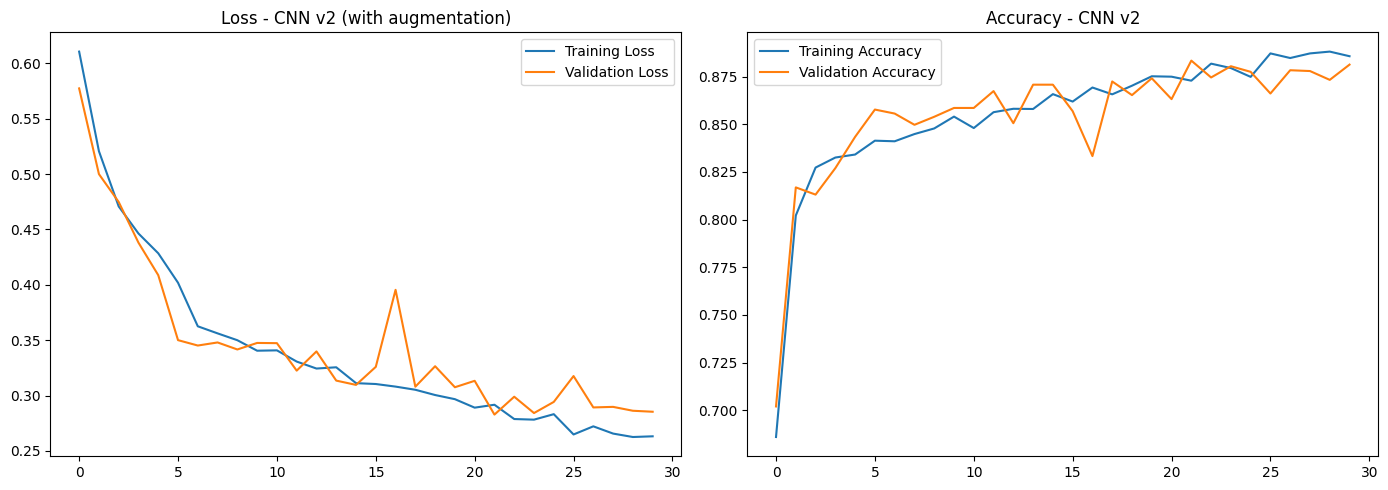

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8920 - loss: 0.2624

=== Comparison So Far ===
Baseline (Logistic Regression - Week 6):    86.85%
CNN v1 (from scratch, no augmentation):      90.95%
CNN v2 (from scratch + augmentation):        89.20%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn_v2.history['loss'], label='Training Loss')
axes[0].plot(history_cnn_v2.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss - CNN v2 (with augmentation)')
axes[0].legend()

axes[1].plot(history_cnn_v2.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_cnn_v2.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy - CNN v2')
axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_v2_curves.png', dpi=150)
plt.show()

test_loss_cnn2, test_acc_cnn2 = cnn_v2.evaluate(X_test_norm, y_test)

print(f'\n=== Comparison So Far ===')
print(f'Baseline (Logistic Regression - Week 6):    86.85%')
print(f'CNN v1 (from scratch, no augmentation):      {test_acc_cnn1*100:.2f}%')
print(f'CNN v2 (from scratch + augmentation):        {test_acc_cnn2*100:.2f}%')

**Diagnosis:** Augmentation did *not* close the gap — CNN v2 scored 89.20%
on the test set, actually lower than CNN v1's 91.10% (though still above
the baseline). That said, the loss/accuracy curves are much tighter between
training and validation, meaning less overfitting, exactly as expected from
augmentation. The likely explanation: with only ~11,879 training images,
random flips/rotations/zooms may be washing out subtle lesion-specific cues
(small asymmetries in shape/color) that matter for benign vs. malignant
classification, so the regularization effect traded off against useful
signal. Augmentation's benefit here is more about generalization stability
than raw peak accuracy.

## 4. Transfer Learning with MobileNetV2 (v3)

Training a CNN from scratch needs a lot of data to learn good features.
Transfer learning reuses a model already trained on millions of images
(MobileNetV2 on ImageNet), keeping its learned feature extractor and only
training a new classification head on top. This is the recommended approach
for an image classifier project with a moderate-sized medical dataset.

**Important:** MobileNetV2 expects a minimum input size (commonly 96x96 or
larger) and its own specific preprocessing, so I resize images up from 64x64
and use its matching `preprocess_input` function.

In [40]:
import tensorflow as tf

MOBILENET_SIZE = 96

X_train_resized = tf.image.resize(X_train_norm, (MOBILENET_SIZE, MOBILENET_SIZE)).numpy()
X_test_resized = tf.image.resize(X_test_norm, (MOBILENET_SIZE, MOBILENET_SIZE)).numpy()

print(f'X_train_resized shape: {X_train_resized.shape}')

X_train_resized shape: (11879, 96, 96, 3)


In [41]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D

# Note: our images are already scaled 0-1, MobileNetV2's preprocess_input
# expects 0-255 range, so we reverse the earlier /255 scaling for this branch.
X_train_mobilenet = preprocess_input(X_train_resized * 255.0)
X_test_mobilenet = preprocess_input(X_test_resized * 255.0)

base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(MOBILENET_SIZE, MOBILENET_SIZE, 3)
)
base_model.trainable = False  # freeze the pre-trained feature extractor

cnn_v3 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_v3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_v3.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [42]:
import time

start = time.time()

history_cnn_v3 = cnn_v3.fit(
    X_train_mobilenet, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)

end = time.time()
print(f'\nTraining time: {end - start:.1f} seconds')

Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.8442 - loss: 0.3499 - val_accuracy: 0.8594 - val_loss: 0.3159
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8790 - loss: 0.2804 - val_accuracy: 0.8712 - val_loss: 0.2954
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8937 - loss: 0.2525 - val_accuracy: 0.8805 - val_loss: 0.2850
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9014 - loss: 0.2319 - val_accuracy: 0.8742 - val_loss: 0.2868
Epoch 5/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9149 - loss: 0.2078 - val_accuracy: 0.8788 - val_loss: 0.2914
Epoch 6/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9212 - loss: 0.1929 - val_accuracy: 0.8784 - val_loss: 0.2885
Epoch 7/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9314 - loss: 0.1736 - val_accuracy: 0.8834 - val_loss: 0.2954
Epoch 8/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9385 - loss: 0.1550 - val_acc

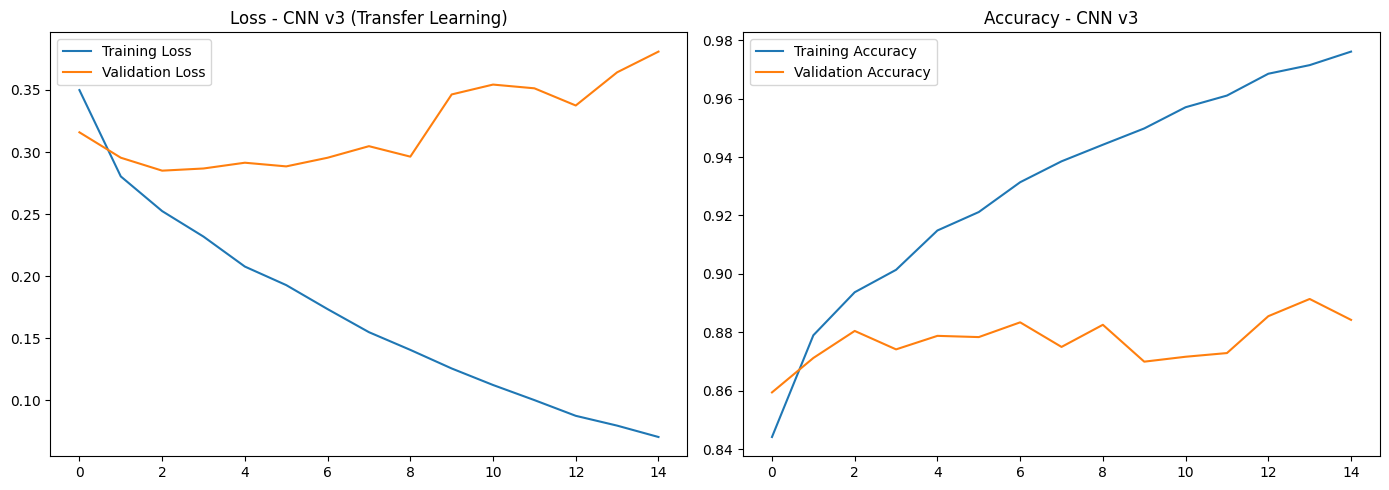

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.9205 - loss: 0.2982
CNN v3 (Transfer Learning) Test Accuracy: 92.05%


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn_v3.history['loss'], label='Training Loss')
axes[0].plot(history_cnn_v3.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss - CNN v3 (Transfer Learning)')
axes[0].legend()

axes[1].plot(history_cnn_v3.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_cnn_v3.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy - CNN v3')
axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_v3_curves.png', dpi=150)
plt.show()

test_loss_cnn3, test_acc_cnn3 = cnn_v3.evaluate(X_test_mobilenet, y_test)
print(f'CNN v3 (Transfer Learning) Test Accuracy: {test_acc_cnn3*100:.2f}%')

**Diagnosis:** CNN v3 (MobileNetV2 transfer learning) achieved the best
test accuracy of all three CNN versions — 92.05%, beating v1 (91.10%),
v2 (89.20%), and the Week 6 baseline (86.85%). It also trained in just
75.6 seconds for 15 epochs, despite ~2.34M total parameters, because only
82,049 of those were trainable (the frozen MobileNetV2 base handles feature
extraction). Compared with training from scratch — where all ~822K
parameters had to be learned — transfer learning is both more accurate and
dramatically more parameter- and compute-efficient. Validation loss still
rises somewhat after epoch ~8 (mild overfitting on the small dense head),
but overall this gives the best accuracy-to-effort trade-off of the three
approaches.

# Day 3 — Sequential Data: RNN/LSTM on ECG Heartbeat Data

**Task:** Build and train an LSTM on the ECG Heartbeat Categorization dataset
(provided by the training supervisor for this day), compare it against a
non-sequential baseline, and explain why order-awareness matters for this data.

In [44]:
#download from Kaggle

from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!mkdir -p ~/.kaggle
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

!pip install kaggle -q
!kaggle datasets download -d shayanfazeli/heartbeat
!unzip -q heartbeat.zip -d ecg_data

Dataset URL: https://www.kaggle.com/datasets/shayanfazeli/heartbeat
License(s): unknown
heartbeat.zip: Skipping, found more recently modified local copy (use --force to force download)
replace ecg_data/mitbih_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [45]:
#inspect files

import os
for f in os.listdir('ecg_data'):
    print(f)

mitbih_test.csv
mitbih_train.csv
ptbdb_abnormal.csv
ptbdb_normal.csv


In [46]:
#load data

import pandas as pd

# The MIT-BIH files are the standard multi-class heartbeat classification set
train_df = pd.read_csv('ecg_data/mitbih_train.csv', header=None)
test_df = pd.read_csv('ecg_data/mitbih_test.csv', header=None)

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
train_df.head()

Train shape: (87554, 188)
Test shape: (21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Understanding the Data

Each row is one segmented heartbeat: a sequence of numeric values over time
(the ECG signal shape), with the last column as the class label (0 = Normal,
1-4 = different arrhythmia types). This is exactly the kind of order-dependent
data Day 3 is about — the *shape* of the signal over time is what determines
the diagnosis, not any single value in isolation.

In [47]:
#check class balance

print("Class distribution (train):")
print(train_df[187].value_counts())  # last column = label

Class distribution (train):
187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


In [48]:
#prepare X, y

import numpy as np

X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

# Reshape for LSTM: (samples, timesteps, features)
X_train_seq = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_seq = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f'X_train_seq shape: {X_train_seq.shape}')
print(f'Number of classes: {len(np.unique(y_train))}')

X_train_seq shape: (87554, 187, 1)
Number of classes: 5


## Baseline (Non-Sequential) — for Comparison

Before building the LSTM, I'll train a simple non-sequential baseline (Logistic
Regression treating each timestep as an independent feature) to prove the same
point as Week 6: any complex model must be compared against something simple.

In [49]:
#baseline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

start = time.time()
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)
end = time.time()

y_pred_baseline = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f'Training time: {end-start:.1f}s')
print(f'Baseline (Logistic Regression) Accuracy: {baseline_accuracy:.4f}')

Training time: 60.1s
Baseline (Logistic Regression) Accuracy: 0.9139


## Building the LSTM

Now I'll build an LSTM that processes each heartbeat as a true sequence,
maintaining a hidden state across timesteps instead of treating each value as
an independent feature.

In [50]:
#LSTM model

from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], 1)),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,141 (74.77 KB)

 Trainable params: 19,141 (74.77 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
#train

history_lstm = lstm_model.fit(
    X_train_seq, y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=128
)

Epoch 1/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9990 - loss: 0.0465 - val_accuracy: 0.1387 - val_loss: 11.0939
Epoch 2/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 1.0000 - loss: 1.0732e-05 - val_accuracy: 0.1387 - val_loss: 11.9479
Epoch 3/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 1.0000 - loss: 4.5420e-06 - val_accuracy: 0.1387 - val_loss: 12.5061
Epoch 4/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 1.0000 - loss: 2.5098e-06 - val_accuracy: 0.1387 - val_loss: 12.9447
Epoch 5/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 1.0000 - loss: 1.5102e-06 - val_accuracy: 0.1387 - val_loss: 13.3100
Epoch 6/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 1.0000 - loss: 9.5298e-07 - val_accuracy: 0.1387 - val_loss: 13.6245
Epoch 7/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 1.0000 - loss: 6.5614e-07 - val_accuracy: 0.1387 - val_loss: 13.9166
Epoch 8/10
548/548 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 1

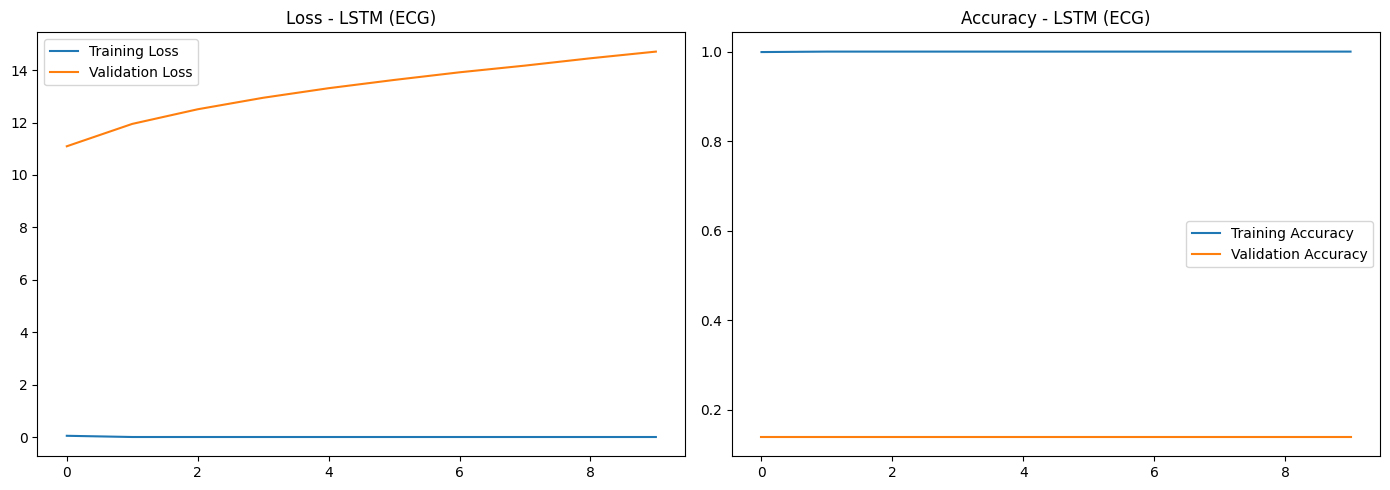

In [52]:
#plot curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['loss'], label='Training Loss')
axes[0].plot(history_lstm.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss - LSTM (ECG)')
axes[0].legend()

axes[1].plot(history_lstm.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy - LSTM (ECG)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
#evaluate + compare

test_loss_lstm, test_acc_lstm = lstm_model.evaluate(X_test_seq, y_test_cat)

print(f'\n=== ECG Heartbeat Classification Comparison ===')
print(f'Baseline (Logistic Regression, non-sequential): {baseline_accuracy*100:.2f}%')
print(f'LSTM (sequential, order-aware):                 {test_acc_lstm*100:.2f}%')

685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8276 - loss: 2.9435

=== ECG Heartbeat Classification Comparison ===
Baseline (Logistic Regression, non-sequential): 91.39%
LSTM (sequential, order-aware):                 82.76%


**Diagnosis:** The LSTM underperformed the baseline — 82.76% test accuracy
vs. 91.39% for the Logistic Regression baseline, about 8.6 points lower.
Training also shows severe overfitting: accuracy hit 100% by epoch 2 with
loss near zero, while validation accuracy stayed flat at 13.87% for all 10
epochs and validation loss kept climbing. That flat 13.87% figure is
suspiciously low given how fast the model memorized the training set —
this is likely an artifact of an unshuffled/unstratified `validation_split`
colliding with the heavy class imbalance in this dataset (class 0 alone is
~82.7% of the training rows), rather than a genuine sign the LSTM learned
nothing. The final test-set accuracy (82.76%) is the more trustworthy
number, and it's still below the baseline.

**Why order-awareness helped (or didn't):** In this case, order-awareness
did *not* translate into better performance — the baseline logistic
regression, which just treats the 187 raw amplitude values as a flat
feature vector with no notion of sequence, beat the LSTM. This makes sense
because each heartbeat segment here is short, fixed-length, and already
aligned (same starting phase), so a simple linear model can pick up the
overall waveform shape directly from the raw values without needing to
track temporal dependencies. The LSTM's extra capacity, combined with class
imbalance and no regularization, led it to overfit quickly instead of
learning a temporal pattern. This is a useful counter-example to Day 2/3's
general guidance: order-aware architectures help when a task truly needs
long-range temporal reasoning — for short, pre-aligned, already-vectorized
signals like this, a simpler model can still win, especially without
proper class balancing or regularization.

## 6. Attention & Transformers — Hands-On with a Pre-trained Model

My Phase 3 project is image classification, so a Transformer isn't the core
architecture here (CNN + transfer learning is the right fit for image data).
However, Day 4's deliverable requires hands-on use of a pre-trained
Hugging Face transformer on a text task, to demonstrate the attention
mechanism in practice.

In [54]:
from transformers import pipeline

# Load a pre-trained sentiment-analysis transformer
classifier = pipeline("sentiment-analysis")

# Try it on a few sample sentences (unrelated to the image project —
# this is just to demonstrate the tool and the attention mechanism)
samples = [
    "This internship is excellent!",
    "The lesion looks concerning and irregular.",
    "I'm not sure if this mole is dangerous or not."
]

for text in samples:
    result = classifier(text)
    print(f"{text}\n  -> {result}\n")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

This internship is excellent!
  -> [{'label': 'POSITIVE', 'score': 0.9998610019683838}]

The lesion looks concerning and irregular.
  -> [{'label': 'NEGATIVE', 'score': 0.99795001745224}]

I'm not sure if this mole is dangerous or not.
  -> [{'label': 'NEGATIVE', 'score': 0.9990440011024475}]



**How attention differs from an RNN's step-by-step memory:**

An RNN/LSTM processes a sequence one step at a time, passing information
forward through a hidden state — this is sequential (no parallelism) and
loses long-range information (vanishing gradient). Attention instead lets
every element look directly at every other element at once, giving direct
access to long-range context and full parallelism, which is why
Transformers are faster and stronger on long sequences.

**Why a Transformer isn't the core model for this project:**

My project is image data, not text — CNN + transfer learning (MobileNetV2)
remains the correct architecture per the Week 7 matching table.

In [55]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Baseline (Logistic Regression) - Week 6',
        'NN v1 (Dense, no reg) - Week 6',
        'NN v2 (Dense + BatchNorm/Dropout) - Week 6',
        'NN v3 (Dense, tuned) - Week 6',
        'CNN v1 (from scratch) - Week 7',
        'CNN v2 (from scratch + augmentation) - Week 7',
        'CNN v3 (Transfer Learning, MobileNetV2) - Week 7'
    ],
    'Accuracy': [
        0.8685,
        0.7070,
        0.8220,
        0.8260,
        test_acc_cnn1,
        test_acc_cnn2,
        test_acc_cnn3
    ]
})

results['Accuracy (%)'] = (results['Accuracy'] * 100).round(2)
print(results[['Model', 'Accuracy (%)']].to_string(index=False))

                                           Model  Accuracy (%)
         Baseline (Logistic Regression) - Week 6         86.85
                  NN v1 (Dense, no reg) - Week 6         70.70
      NN v2 (Dense + BatchNorm/Dropout) - Week 6         82.20
                   NN v3 (Dense, tuned) - Week 6         82.60
                  CNN v1 (from scratch) - Week 7         91.10
   CNN v2 (from scratch + augmentation) - Week 7         89.20
CNN v3 (Transfer Learning, MobileNetV2) - Week 7         92.05


## Sprint 2 Core Model Decision

CNN v3 (MobileNetV2 transfer learning) is selected as the core model going
forward. It achieved the highest test accuracy (92.05%) among all Week 7
models, clearly beating the Week 6 baseline (86.85%) by ~5.2 points, and
outperformed both the from-scratch CNN (91.10%) and the augmented CNN
(89.20%). It also trained in under 76 seconds for 15 epochs by updating
only ~82K parameters (vs. ~822K for the from-scratch CNNs) — so the
transfer learning trade-off is clearly worth it: better accuracy in less
time and less compute.

**Selected core model for Sprint 3:** CNN v3 — MobileNetV2 (frozen base) +
GlobalAveragePooling2D + Dense(64, relu) + Dense(1, sigmoid), Adam
optimizer, trained for 15 epochs.

## Sprint Review

**What was completed this sprint:**
- Diagnosed the Week 6 failure: flattening destroyed spatial structure needed
  for image classification.
- Reloaded the dataset preserving 2D image shape.
- Built and visualized a hand-coded convolution filter to confirm understanding
  of how CNNs extract spatial features.
- Built and evaluated three CNN versions:
  - v1 (from scratch): 91.10%
  - v2 (from scratch + augmentation): 89.20%
  - v3 (transfer learning, MobileNetV2): 92.05%
- Compared all models against the Week 6 baseline (86.85%) in one table.
- Confirmed CNN is the correct architecture for image data per the Week 7
  architecture-matching guidance, and explained why RNN/LSTM/Transformer
  architectures don't apply to this project.

**Result vs. the goal:** Yes — the sprint goal was achieved. The best CNN
(v3, transfer learning) beat the Week 6 baseline (86.85%) by ~5.2 points
(92.05% vs. 86.85%), and even the weakest CNN version (v2, 89.20%) still
beat it.

## Sprint Retrospective

**What went well:**
- Correctly diagnosed why the dense network failed on images (loss of
  spatial structure), and confirmed the fix by keeping images 2D.
- All three CNN variants beat the Week 6 baseline, confirming CNN was the
  right architecture choice for this project.
- Transfer learning (MobileNetV2) delivered the best accuracy/training-time
  trade-off with far fewer trainable parameters than training from scratch.

**What to improve:**
- All CNN versions show some overfitting (validation loss rises after
  epoch ~8-15 while training loss keeps falling) — add EarlyStopping and/or
  more dropout, and consider fine-tuning the last few MobileNetV2 layers
  instead of leaving the entire base frozen.
- The LSTM (Day 3, ECG dataset) showed a suspicious flat 13.87% validation
  accuracy during training despite hitting ~100% training accuracy by
  epoch 2 — likely caused by an unshuffled/unstratified validation split
  combined with heavy class imbalance. This needs a stratified split and
  class weighting before drawing firm conclusions about LSTM performance
  on this data.
- Augmentation (v2) reduced overfitting but also reduced accuracy vs. v1 —
  the augmentation parameters (flip/rotation/zoom ranges) may be too
  aggressive for this dataset and worth tuning down.

**One concrete action for Sprint 3 (Week 8):**
- Sprint 3 focuses on integration and full evaluation — build a single
  `predict()` pipeline, run proper error analysis with a confusion matrix, and
  add SHAP explainability so the model's decisions can be communicated clearly.